In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import preliz as pz

In [2]:
az.style.use("arviz-variat")
az.rcParams["stats.ci_kind"] = "hdi"
az.rcParams["stats.ci_prob"] = 0.94
SEED = 4591

In [3]:
cs_data = pd.read_csv('data/chemical_shifts_theo_exp.csv')
diff = cs_data.theo - cs_data.exp
cat_encode = pd.Categorical(cs_data['aa'])
idx = cat_encode.codes
coords = {"aa": cat_encode.categories}

In [4]:
with pm.Model(coords=coords) as cs_nh:         
    μ = pm.Normal('μ', mu=0, sigma=10, dims="aa") 
    σ = pm.HalfNormal('σ', sigma=10, dims="aa") 
 
    y = pm.Normal('y', mu=μ[idx], sigma=σ[idx], observed=diff) 
     
    idata_cs_nh = pm.sample(random_seed=SEED)

NUTS[nutpie]: [μ, σ]


Output()

In [5]:
with pm.Model(coords=coords) as cs_h:
    # hyper_priors
    μ_mu = pm.Normal('μ_mu', mu=0, sigma=10)
    μ_sd = pm.HalfNormal('μ_sd', 10)

    # priors
    μ = pm.Normal('μ', mu=μ_mu, sigma=μ_sd, dims="aa") 
    σ = pm.HalfNormal('σ', sigma=10, dims="aa") 

    y = pm.Normal('y', mu=μ[idx], sigma=σ[idx], observed=diff) 

    idata_cs_h = pm.sample(random_seed=SEED)

NUTS[nutpie]: [μ_mu, μ_sd, μ, σ]


Output()

In [6]:
idata_cs_h.posterior['μ_mu'].mean().item()

0.06707391148049226

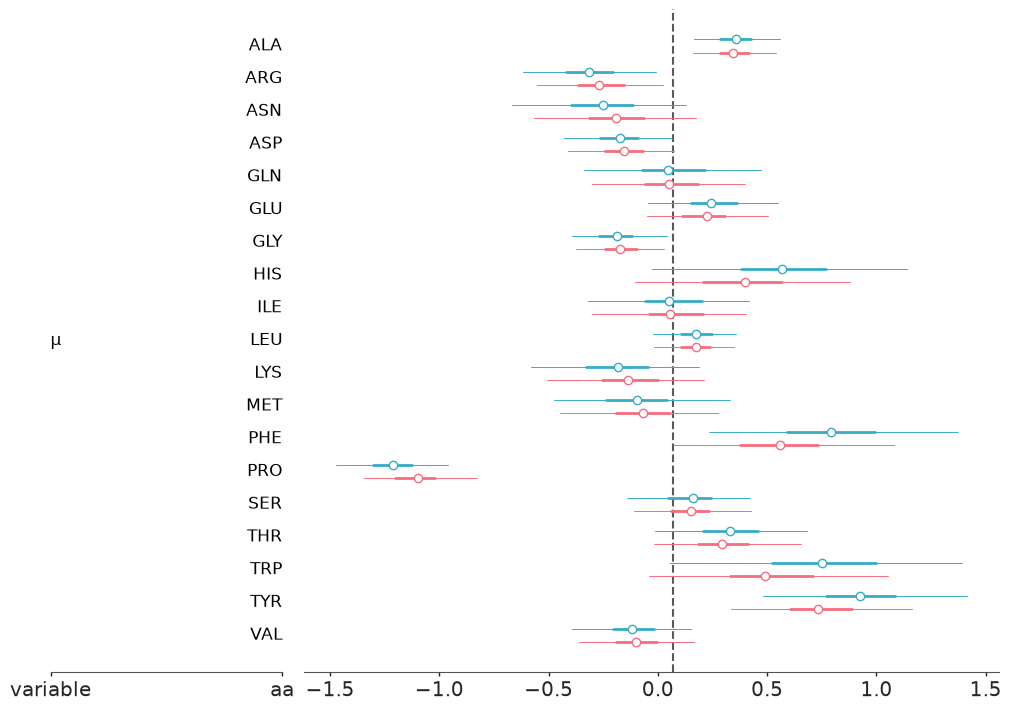

In [7]:
pc = az.plot_forest({"non_hierarchical": idata_cs_nh, "hierarchical": idata_cs_h},
                    var_names='μ', combined=True,
                    figure_kwargs={"figsize": (10, 7)})
pc.coords = {"column": "forest"}
az.add_lines(pc, idata_cs_h.posterior['μ_mu'].mean().item());

In [8]:
# for name, model in zip(("cs_nh", "cs_h"), (cs_nh, cs_h)):
#     graph = pm.model_to_graphviz(model)
#     graph.graph_attr.update(size="2,2!")
#     graph.graph_attr.update(dpi="300")
#     graph.render(filename=name, format="png", cleanup=True)

In [9]:
N_samples = [30, 30, 30]
G_samples = [18, 18, 18]
group_idx = np.repeat(np.arange(len(N_samples)), N_samples)
data = []
for i in range(0, len(N_samples)):
    data.extend(np.repeat([1, 0], [G_samples[i], N_samples[i]-G_samples[i]]))

In [10]:
with pm.Model() as model_h:
    # hypyerpriors
    μ = pm.Beta('μ', 1., 1.)
    ν = pm.HalfNormal('ν', 10)
    # prior
    θ = pm.Beta('θ', mu=μ, nu=ν, shape=len(N_samples))
    # likelihood
    y = pm.Bernoulli('y', p=θ[group_idx], observed=data)

    idata_h = pm.sample(random_seed=SEED)
    

NUTS[nutpie]: [μ, ν, θ]


Output()

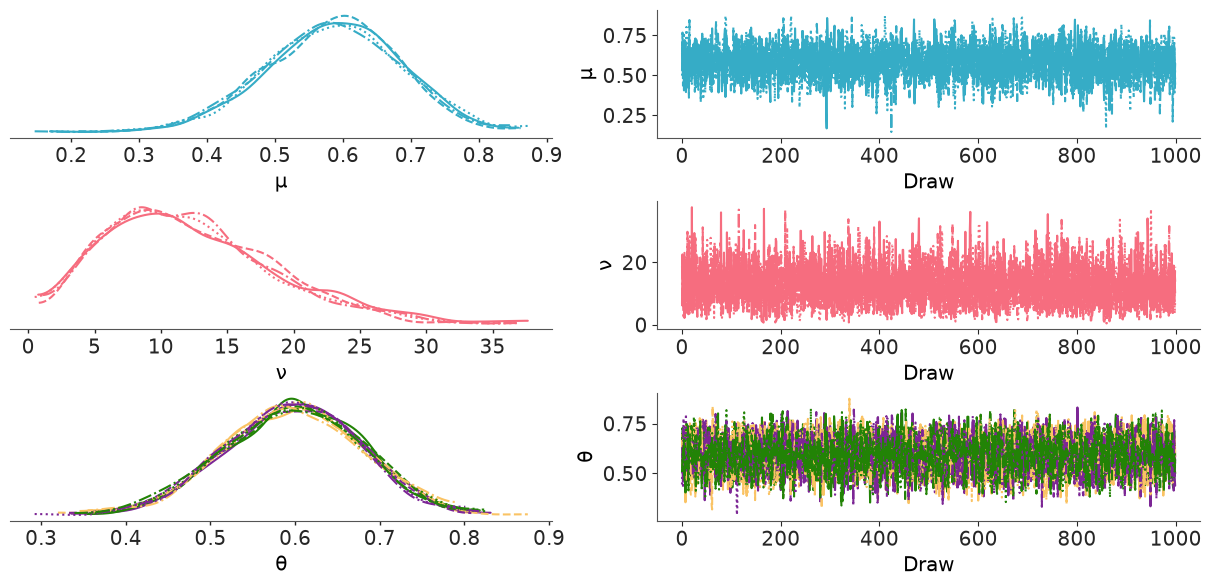

In [11]:
az.plot_trace_dist(idata_h);

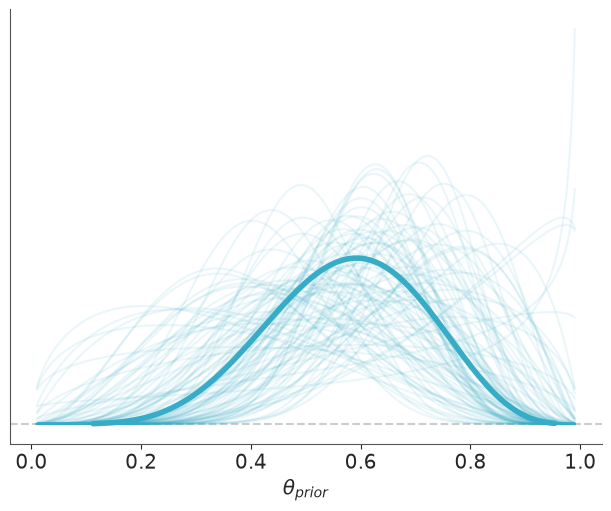

In [12]:

posterior = az.extract(idata_h, num_samples=100)
for sample in posterior[["μ", "ν"]].to_array().values.T:
    pz.Beta(mu=sample[0], nu=sample[1]).plot_pdf(legend=None,
                                                 color="C0", 
                                                 alpha=0.1,
                                                 support=(0.01, 0.99),
                                                 baseline=False)

ax = pz.Beta(mu=posterior["μ"].mean().item(), 
             nu=posterior["ν"].mean().item()).plot_pdf(legend=None, 
                                                       color="C0", 
                                                       lw=4)
ax.set_xlabel('$θ_{prior}$');


In [13]:
football = pd.read_csv("data/football_players.csv", dtype={'position':'category'})
football

,name,position,goals,shots
0,Aaron Connolly,FW,5,59
1,Aaron Cresswell,DF,4,69
2,Aaron Hunt,MF,3,30
3,Aaron Lennon,MF,1,5
4,Aaron Leya Iseka,FW,10,76
...,...,...,...,...
2677,Óscar Mingueza,DF,2,12
2678,Óscar Plano,MF,12,124
2679,Óscar Rodríguez,MF,13,133
2680,Óscar Trejo,MF,1,20


In [14]:
pos_idx = football.position.cat.codes.values
pos_codes = football.position.cat.categories
n_pos = pos_codes.size
n_players = football.index.size

In [15]:
coords = {"pos": pos_codes}
with pm.Model(coords=coords) as model_football:
    # Hyper parameters
    μ = pm.Beta('μ', 1.7, 5.8) 
    ν = pm.Gamma('ν', mu=125, sigma=50)

    
    # Parameters for positions
    μ_p = pm.Beta('μ_p',
                       mu=μ,
                       nu=ν,
                       dims = "pos")
    
    ν_p = pm.Gamma('ν_p', mu=125, sigma=50, dims="pos")
 
    # Parameter for players
    θ = pm.Beta('θ', 
                    mu=μ_p[pos_idx],
                    nu=ν_p[pos_idx])
    
    _ = pm.Binomial('gs', n=football.shots.values, p=θ, observed=football.goals.values)

    idata_football = pm.sample(draws=3000, target_accept=0.95, random_seed=SEED)

NUTS[nutpie]: [μ, ν, μ_p, ν_p, θ]


Output()

In [16]:
# graph = pm.model_to_graphviz(model_football)
# graph.graph_attr.update(size="4,4!")
# graph.graph_attr.update(dpi="300")
# graph.render(filename="beta_binomial_hierarchical_subjects_dag", format="png", cleanup=True)

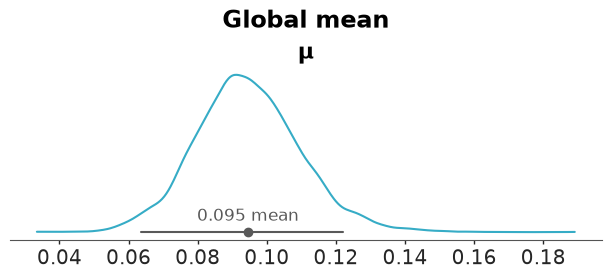

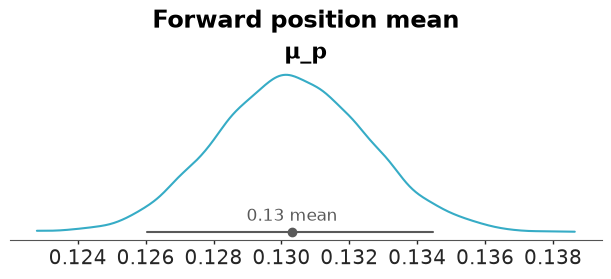

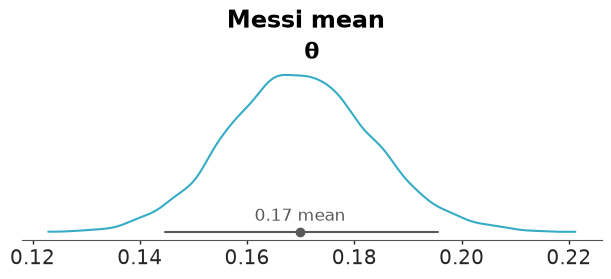

In [17]:
#_, ax = plt.subplots(3, 1, figsize=(12, 6), sharex=True)
pc = az.plot_dist(idata_football, var_names='μ')
pc.add_title("Global mean")
pc = az.plot_dist(idata_football, var_names='μ_p', coords={"pos": "FW"})
pc.add_title("Forward position mean")
pc = az.plot_dist(idata_football, var_names='θ', coords={"θ_dim_0": 1457})
pc.add_title("Messi mean")


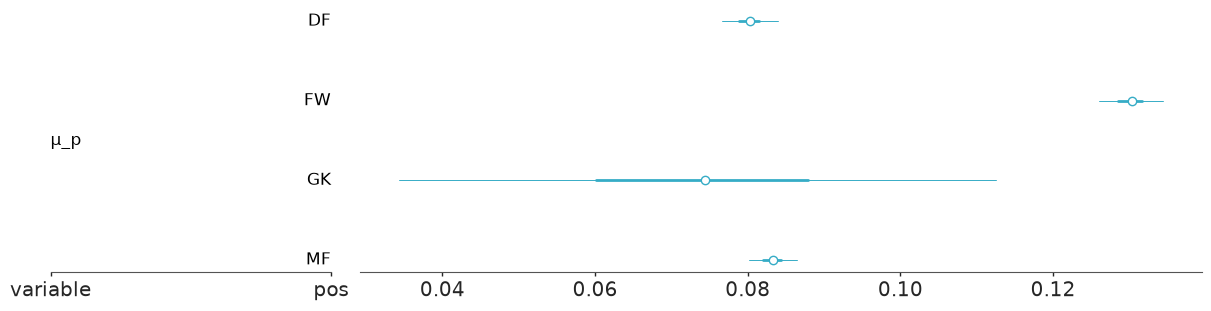

In [18]:
az.plot_forest(idata_football, var_names=['μ_p'], combined=True, figure_kwargs={"figsize": (12, 3)});